In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from pyts.transformation import ShapeletTransform
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

In [3]:
df = pd.read_csv('power_daily_clean.csv')
data = df['Global_active_power'].values

In [4]:
X, y = [], []
window_size = 7

for i in range(len(data) - window_size):
    X.append(data[i:i+window_size])
    y.append(1 if np.mean(data[i:i+window_size]) > 1.6 else 0)

X = np.array(X)
y = np.array(y)

In [5]:
st = ShapeletTransform(n_shapelets=2, window_sizes=[3, 5])
X_new = st.fit_transform(X, y)

In [6]:
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [7]:
st = ShapeletTransform(n_shapelets=3, window_sizes=[3, 4, 5], random_state=42)
X_train_st = st.fit_transform(X_train, y_train)
X_test_st = st.transform(X_test)

In [8]:
clf = DecisionTreeClassifier(max_depth=3, criterion='entropy')
clf.fit(X_train_st, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

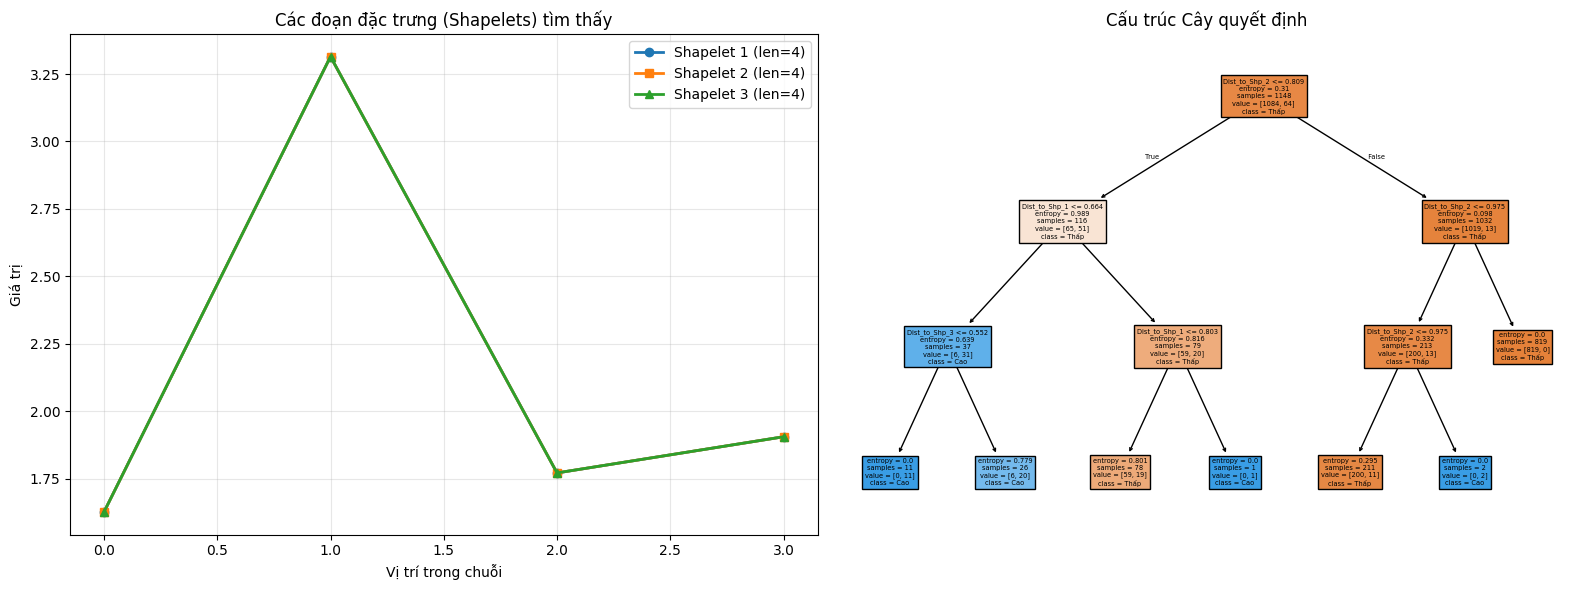

Độ chính xác trên tập Test: 100.00%


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

import matplotlib.cm as cm
n_sh = len(st.shapelets_)
colors = [cm.tab10(i) for i in range(n_sh)]
styles = ['-o', '-s', '-^', '-D', '-v'][:n_sh]

for i, s in enumerate(st.shapelets_):
    ax1.plot(s, styles[i], color=colors[i],
             label=f'Shapelet {i+1} (len={len(s)})',
             linewidth=2, markersize=6)

ax1.set_title("Các đoạn đặc trưng (Shapelets) tìm thấy")
ax1.legend()
ax1.set_xlabel("Vị trí trong chuỗi")
ax1.set_ylabel("Giá trị")
ax1.grid(True, alpha=0.3)

plot_tree(clf, filled=True,
          feature_names=[f"Dist_to_Shp_{i+1}" for i in range(n_sh)],
          class_names=['Thấp', 'Cao'], ax=ax2)
ax2.set_title("Cấu trúc Cây quyết định")

plt.tight_layout()
plt.show()

print(f"Độ chính xác trên tập Test: {clf.score(X_test_st, y_test)*100:.2f}%")

In [ ]:
data_X = np.array(X)
data_y = np.array(y)
X_train, X_test, y_train, y_test = train_test_split(data_X, data_y, test_size=0.2, random_state=42)

print(f"Kích thước tập huấn luyện: {X_train.shape}")
print(f"Kích thước tập kiểm tra: {X_test.shape}")
print("-" * 30)

Kích thước tập huấn luyện: (1148, 7)
Kích thước tập kiểm tra: (287, 7)
------------------------------


In [31]:
# 1. MÔ HÌNH K-NEAREST NEIGHBORS (K-NN)
knn_model = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)

print(f"Độ chính xác mô hình KNN: {acc_knn*100:.2f}%")
print("-" * 30)

Độ chính xác mô hình KNN: 96.86%
------------------------------


In [30]:
# 2. MÔ HÌNH SUPPORT VECTOR MACHINE (SVM)
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)

print(f"Độ chính xác mô hình SVM: {acc_svm*100:.2f}%")
print("-" * 30)

Độ chính xác mô hình SVM: 97.21%
------------------------------


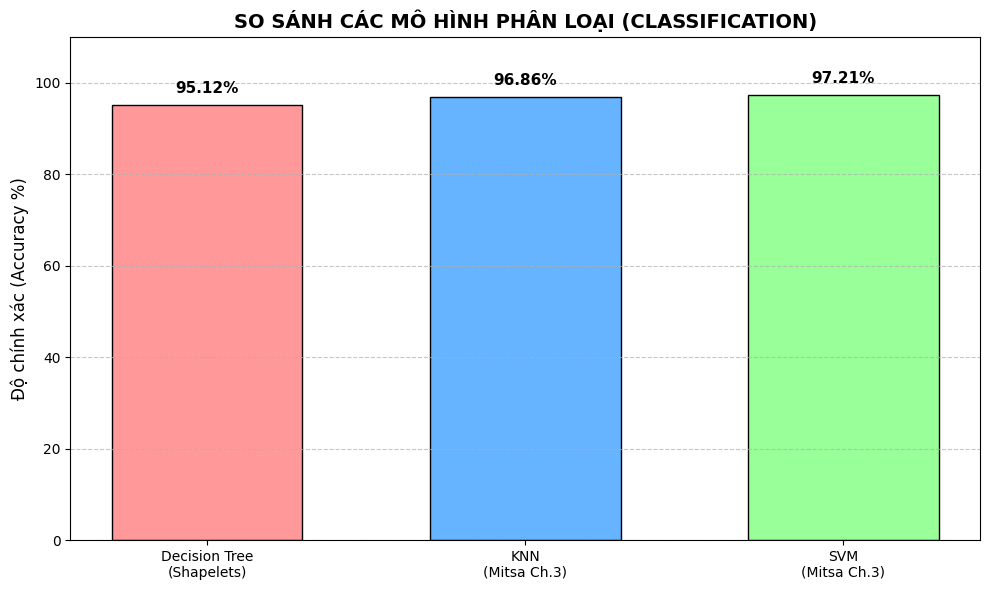


BÁO CÁO CHI TIẾT MÔ HÌNH SVM:
              precision    recall  f1-score   support

    Thấp (0)       0.97      1.00      0.99       273
     Cao (1)       1.00      0.43      0.60        14

    accuracy                           0.97       287
   macro avg       0.99      0.71      0.79       287
weighted avg       0.97      0.97      0.97       287



In [ ]:
try:
    y_pred_dt = clf.predict(X_test_st)
    acc_dt = accuracy_score(y_test, y_pred_dt)
except:
    acc_dt = 0 

# 3. VẼ BIỂU ĐỒ SO SÁNH TỔNG HỢP
models = ['Decision Tree\n(Shapelets)', 'KNN\n(Mitsa Ch.3)', 'SVM\n(Mitsa Ch.3)']
scores = [acc_dt * 100, acc_knn * 100, acc_svm * 100]

plt.figure(figsize=(10, 6))
colors = ['#ff9999','#66b3ff','#99ff99']
bars = plt.bar(models, scores, color=colors, edgecolor='black', width=0.6)

plt.ylabel('Độ chính xác (Accuracy %)', fontsize=12)
plt.title('SO SÁNH CÁC MÔ HÌNH PHÂN LOẠI (CLASSIFICATION)', fontsize=14, fontweight='bold')
plt.ylim(0, 110)

# Ghi số liệu cụ thể lên đầu mỗi cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{height:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 4. HIỂN THỊ CHI TIẾT ĐÁNH GIÁ (Dùng cho báo cáo)
print("\nBÁO CÁO CHI TIẾT MÔ HÌNH SVM:")
print(classification_report(y_test, y_pred_svm, target_names=['Thấp (0)', 'Cao (1)']))